<a href="https://colab.research.google.com/github/aliya-fatma011/Deep-Learning/blob/main/CassavaEfficientnetLite_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!cp -r /content/drive/MyDrive/cln_dataset /content/cln_dataset
!pip install -q tensorflow_hub

Mounted at /content/drive


## 1. Imports & Configuration

In [ ]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import tensorflow_hub as hub

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ── Enable mixed precision (speeds up training on T4/V100/A100 GPUs) ──
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))
print("Mixed precision policy:", mixed_precision.global_policy().name)

TF version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision policy: mixed_float16


## 2. Paths & Hyperparameters

In [ ]:
BASE_PATH  = "/content/cln_dataset"
TRAIN_DIR  = BASE_PATH + "/Train/Train_Images_clean"
TEST_DIR   = BASE_PATH + "/Test/Test_Images_clean"
TRAIN_CSV  = BASE_PATH + "/Train/Train.csv"
TEST_CSV   = BASE_PATH + "/Test/Test.csv"
LABEL_JSON = BASE_PATH + "/label_num_to_disease_map.json"

# ── Key hyperparameters ──
IMG_SIZE   = 260          # EfficientNet-Lite2 native size
BATCH_SIZE = 32           # Increased from 16 → faster epochs
EPOCHS     = 20           # EarlyStopping will cut this short
LR         = 3e-4         # Slightly higher LR works well with Adam + warmup
AUTOTUNE   = tf.data.AUTOTUNE

with open(LABEL_JSON) as f:
    label_map = json.load(f)

num_classes = len(label_map)
print("Classes:", num_classes)
for k, v in label_map.items():
    print(f"  {k}: {v}")

Classes: 5
  0: CBB
  1: CBSD
  2: CGM
  3: CMD
  4: Healthy


## 3. Load & Split Data

Train: 3200  |  Val: 800  |  Test: 1000


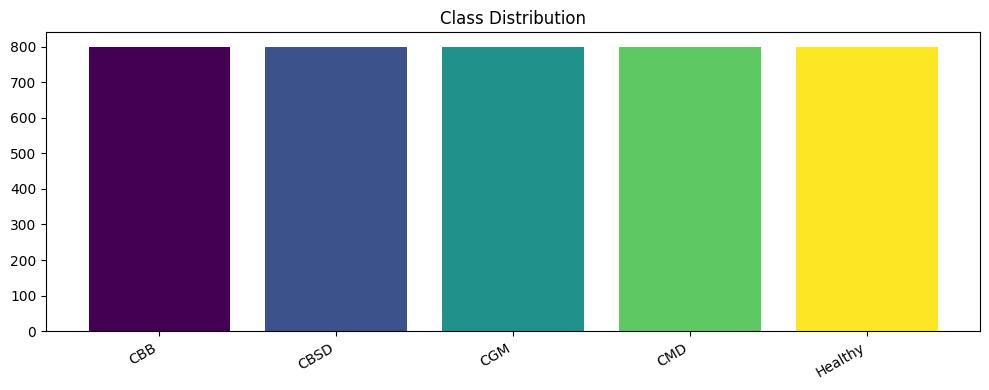

In [ ]:
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

train_df["Labels"] = train_df["Labels"].astype(str)
test_df["Labels"]  = test_df["Labels"].astype(str)

# Full paths
train_df["path"] = train_df["ID"].apply(lambda x: os.path.join(TRAIN_DIR, x))
test_df["path"]  = test_df["ID"].apply(lambda x: os.path.join(TEST_DIR, x))

train_data, val_data = train_test_split(
    train_df, test_size=0.2, random_state=42, stratify=train_df["Labels"]
)
print(f"Train: {len(train_data)}  |  Val: {len(val_data)}  |  Test: {len(test_df)}")

# Class distribution
counts = train_df["Labels"].value_counts().sort_index()
plt.figure(figsize=(10, 4))
plt.bar([label_map[k] for k in counts.index], counts.values, color=plt.cm.viridis(np.linspace(0,1,num_classes)))
plt.xticks(rotation=30, ha='right')
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

## 4. tf.data Pipeline (replaces slow ImageDataGenerator)

In [ ]:
# ── Build label encoder from sorted unique labels ──
class_names = sorted(train_df["Labels"].unique())
label_to_idx = {lbl: idx for idx, lbl in enumerate(class_names)}
print("Label index map:", label_to_idx)

def parse_image(path, label):
    """Load, decode, resize a single image."""
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

# ── Augmentation (applied only to train set, on-GPU) ──
def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.15)
    img = tf.image.random_contrast(img, 0.85, 1.15)
    img = tf.image.random_saturation(img, 0.85, 1.15)
    img = tf.image.random_hue(img, 0.05)
    # Random rotation via keras layer is done inside model (see below)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

def make_dataset(df, training=False):
    paths  = df["path"].values
    labels = tf.keras.utils.to_categorical(
        [label_to_idx[l] for l in df["Labels"]], num_classes=num_classes
    )
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(parse_image, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(buffer_size=2000, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_data, training=True)
val_ds   = make_dataset(val_data,   training=False)
test_ds  = make_dataset(test_df,    training=False)

print("Train batches:", len(train_ds))
print("Val   batches:", len(val_ds))

Label index map: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}
Train batches: 100
Val   batches: 25


## 5. Model — EfficientNet-Lite2 (Frozen Base + Custom Head)

In [ ]:
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras import layers

EFFICIENTNET_LITE2_URL = "https://tfhub.dev/tensorflow/efficientnet/lite2/feature-vector/2"

# ── Fix: wrap hub.KerasLayer in a proper Keras Layer subclass ──
@tf.keras.saving.register_keras_serializable()
class EfficientNetLite2(tf.keras.layers.Layer):
    def __init__(self, trainable=False, **kwargs):
        super().__init__(**kwargs)
        self._hub_layer = hub.KerasLayer(
            EFFICIENTNET_LITE2_URL,
            trainable=trainable
        )
        self._hub_layer.trainable = trainable

    def call(self, inputs, training=False):
        # Cast inside call() — operates on real tensors, not KerasTensors
        x = tf.cast(inputs, tf.float32)
        return self._hub_layer(x, training=training)

    def get_config(self):
        config = super().get_config()
        config["trainable"] = self._hub_layer.trainable
        return config


def build_model(trainable_base=False, lr=LR):
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image_input")

    # In-model augmentation
    x = layers.RandomRotation(0.1)(inputs)
    x = layers.RandomZoom(0.1)(x)

    # Use the wrapper — no Lambda, no hub.KerasLayer directly in the graph
    x = EfficientNetLite2(trainable=trainable_base, name="efficientnet_lite2")(x)

    x = layers.Dense(512, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax", dtype="float32", name="predictions")(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=["accuracy"]
    )
    return model

model = build_model(trainable_base=False)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 260, 260, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_9               │ (None, 260, 260, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_9 (RandomZoom)      │ (None, 260, 260, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnet_lite2              │ (None, 1280)           │             0 │
│ (EfficientNetLite2)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 791,557 (3.02 MB)

 Trainable params: 790,021 (3.01 MB)

 Non-trainable params: 1,536 (6.00 KB)

## 6. Callbacks

In [ ]:
def get_callbacks(ckpt_name="best_model.keras"):
    return [
        ModelCheckpoint(
            ckpt_name,
            monitor="val_accuracy", save_best_only=True, mode="max", verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss", factor=0.3, patience=3, min_lr=1e-7, verbose=1
        ),
        EarlyStopping(
            monitor="val_accuracy", patience=5,   # raised from 3 → avoids premature stop
            restore_best_weights=True, mode="max", verbose=1
        ),
    ]

## 7. Phase 1 — Train Head Only (Frozen Base)

In [ ]:
history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=get_callbacks("best_phase1.keras"),
    verbose=1
)

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.3220 - loss: 2.0148
Epoch 1: val_accuracy improved from None to 0.44000, saving model to best_phase1.keras

Epoch 1: finished saving model to best_phase1.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 32s 133ms/step - accuracy: 0.3641 - loss: 1.8612 - val_accuracy: 0.4400 - val_loss: 1.3582 - learning_rate: 3.0000e-04
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.4428 - loss: 1.5830
Epoch 2: val_accuracy improved from 0.44000 to 0.47500, saving model to best_phase1.keras

Epoch 2: finished saving model to best_phase1.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 37s 155ms/step - accuracy: 0.4366 - loss: 1.5748 - val_accuracy: 0.4750 - val_loss: 1.2746 - learning_rate: 3.0000e-04
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.4393 - loss: 1.5465
Epoch 3: val_accuracy improved from 0.47500 to 0.51625, saving model to best_phase1.keras

Epoch 3: finished saving model to best_phase1.keras
100/100 ━━━━━━

In [ ]:
# Replace custom_objects with your new wrapper class
best_model = tf.keras.models.load_model(
    "best_phase1.keras",
    custom_objects={"EfficientNetLite2": EfficientNetLite2}
)

## 8. Phase 2 — Fine-tune (Unfreeze Base at Lower LR)
> This is the key step to push accuracy beyond 90%.

In [ ]:
# Reload the best checkpoint from phase 1
model = tf.keras.models.load_model(
    "best_phase1.keras",
    custom_objects={"EfficientNetLite2": EfficientNetLite2}
)

# Unfreeze the base
for layer in model.layers:
    layer.trainable = True

# Re-compile with a much lower LR to avoid destroying learned features
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),   # 10x–30x lower
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"]
)

print("Trainable params after unfreezing:", sum(tf.size(v).numpy() for v in model.trainable_variables))

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=get_callbacks("best_phase2.keras"),
    verbose=1
)

Trainable params after unfreezing: 790021
Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.5745 - loss: 1.1889
Epoch 1: val_accuracy improved from None to 0.57625, saving model to best_phase2.keras

Epoch 1: finished saving model to best_phase2.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 25s 147ms/step - accuracy: 0.5700 - loss: 1.1920 - val_accuracy: 0.5763 - val_loss: 1.1375 - learning_rate: 1.0000e-05
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.5549 - loss: 1.1890
Epoch 2: val_accuracy improved from 0.57625 to 0.57750, saving model to best_phase2.keras

Epoch 2: finished saving model to best_phase2.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 121ms/step - accuracy: 0.5691 - loss: 1.1671 - val_accuracy: 0.5775 - val_loss: 1.1368 - learning_rate: 1.0000e-05
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.5668 - loss: 1.1850
Epoch 3: val_accuracy did not improve from 0.57750
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - accuracy: 0.5591 - 

## 9. Training Curves

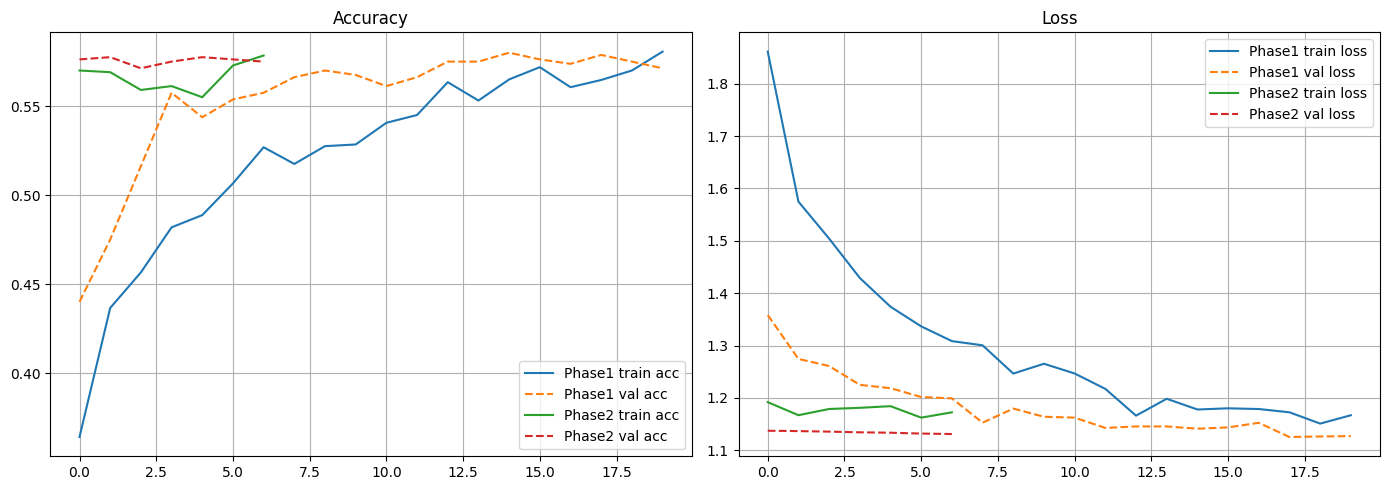

In [ ]:
def plot_history(histories, labels):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for h, lbl in zip(histories, labels):
        axes[0].plot(h.history["accuracy"],     label=f"{lbl} train acc")
        axes[0].plot(h.history["val_accuracy"], label=f"{lbl} val acc", linestyle="--")
        axes[1].plot(h.history["loss"],         label=f"{lbl} train loss")
        axes[1].plot(h.history["val_loss"],     label=f"{lbl} val loss", linestyle="--")
    for ax, title in zip(axes, ["Accuracy", "Loss"]):
        ax.set_title(title); ax.legend(); ax.grid(True)
    plt.tight_layout(); plt.show()

plot_history([history_phase1, history_phase2], ["Phase1", "Phase2"])

## 10. Evaluation

25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.5775 - loss: 1.1368

Val Accuracy: 0.5775  |  Val Loss: 1.1368
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step

Classification Report:
              precision    recall  f1-score   support

         CBB       0.66      0.69      0.67       160
        CBSD       0.59      0.48      0.53       160
         CGM       0.54      0.64      0.58       160
         CMD       0.70      0.53      0.60       160
     Healthy       0.45      0.55      0.50       160

    accuracy                           0.58       800
   macro avg       0.59      0.58      0.58       800
weighted avg       0.59      0.58      0.58       800



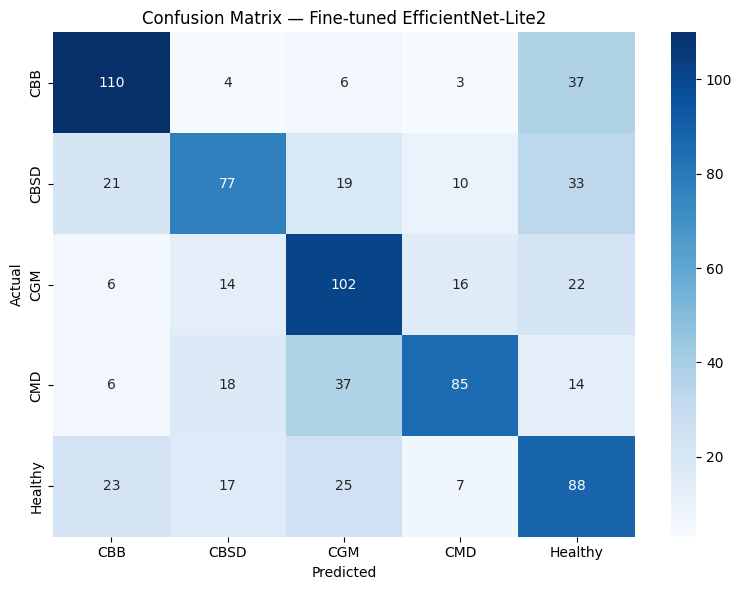

In [ ]:
best_model = tf.keras.models.load_model(
    "best_phase2.keras",
    custom_objects={"KerasLayer": hub.KerasLayer}
)

val_loss, val_acc = best_model.evaluate(val_ds)
print(f"\nVal Accuracy: {val_acc:.4f}  |  Val Loss: {val_loss:.4f}")

# Predictions
y_pred_probs = best_model.predict(val_ds)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in val_ds])

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=[label_map[c] for c in class_names]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[label_map[c] for c in class_names],
            yticklabels=[label_map[c] for c in class_names])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix — Fine-tuned EfficientNet-Lite2")
plt.tight_layout(); plt.show()